Import libraries

In [2]:
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

Load data

In [3]:
fruit_2022 = pd.read_csv("FruitPrices2022.csv")
fruit_2020 = pd.read_csv("FruitPrices2020.csv")
veg_2020 = pd.read_csv("VegetablePrices2020.csv")
veg_2022 = pd.read_csv("VegetablePrices2022.csv")

veg_2022["Name"] = veg_2022["Vegetable"]
veg_2022["Category"] = "Vegetable"
veg_2022["Year"] = 2022

fruit_2022["Name"] = fruit_2022["Fruit"]
fruit_2022["Category"] = "Fruit"
fruit_2022["Year"] = 2022

veg_2020["Name"] = veg_2020["Vegetable"]
veg_2020["Category"] = "Vegetable"
veg_2020["Year"] = 2020

fruit_2020["Name"] = fruit_2020["Fruit"]
fruit_2020["Category"] = "Fruit"
fruit_2020["Year"] = 2020


combine and organize

In [4]:
combined = pd.concat([veg_2022, fruit_2022, veg_2020, fruit_2020], ignore_index = True)
organized = combined.sort_values(by = ["Category", "Name", "Form"])

load GDP data and merge

In [5]:
gdp = pd.read_csv("GDP.csv", header=0)

# Fix column names by converting float years to int strings
gdp.columns = [str(int(col)) if isinstance(col, float) else col for col in gdp.columns]
gdp.columns = gdp.columns.str.strip()  # clean extra whitespace
print(gdp.columns.tolist())


['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']


In [6]:
gdp_us = gdp[gdp["Country Name"] == "United States"][["2020", "2022"]]

gdp_manual = pd.DataFrame({
    "Year": [2020, 2022],
    "GDP": gdp_us.iloc[0].astype(float).values
})

combined_with_gdp = organized.merge(gdp_manual, on="Year", how="left")


In [7]:
print(f"Total records: {len(combined_with_gdp)}")
print(f"Unique produce items: {combined_with_gdp['Name'].nunique()}")
print(f"Years covered: {sorted(combined_with_gdp['Year'].unique())}")

Total records: 310
Unique produce items: 119
Years covered: [np.int64(2020), np.int64(2022)]


filter by year

In [8]:
data_2020 = combined_with_gdp[combined_with_gdp["Year"] == 2020]
data_2022 = combined_with_gdp[combined_with_gdp["Year"] == 2022]

plot

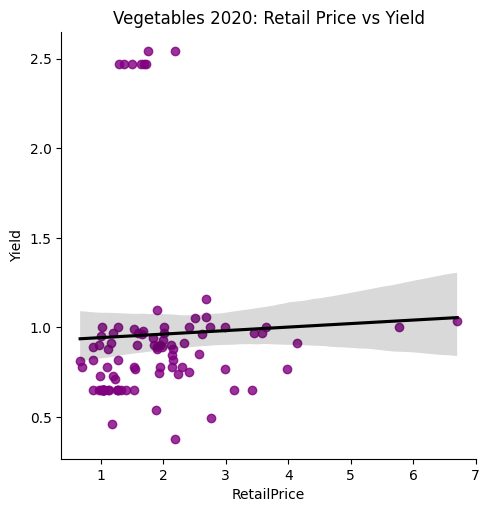

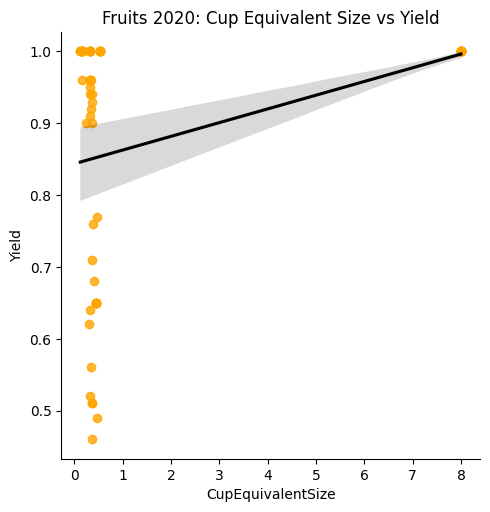

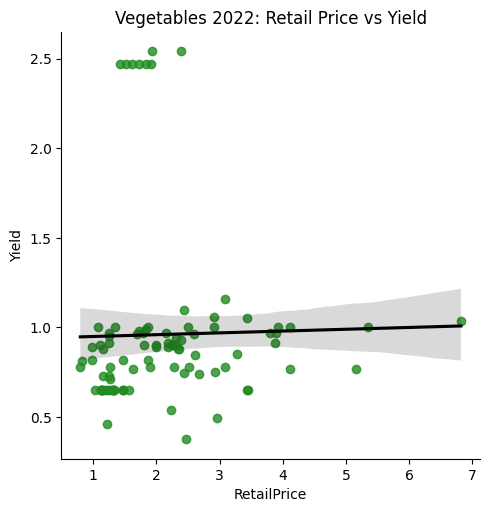

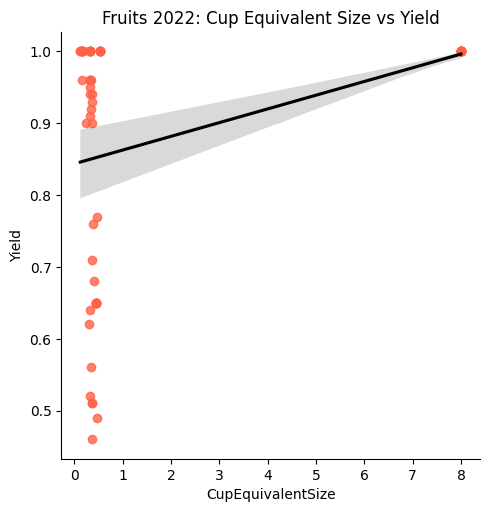

In [9]:
# 2020 - Vegetables
sns.lmplot(data=data_2020[data_2020["Category"] == "Vegetable"],
           x="RetailPrice", y="Yield",
           scatter_kws={'color': 'purple'},
           line_kws={'color': 'black'})
plt.title("Vegetables 2020: Retail Price vs Yield")
plt.show()

# 2020 - Fruits
sns.lmplot(data=data_2020[data_2020["Category"] == "Fruit"],
           x="CupEquivalentSize", y="Yield",
           scatter_kws={'color': 'orange'},
           line_kws={'color': 'black'})
plt.title("Fruits 2020: Cup Equivalent Size vs Yield")
plt.show()

# 2022 - Vegetables
sns.lmplot(data=data_2022[data_2022["Category"] == "Vegetable"],
           x="RetailPrice", y="Yield",
           scatter_kws={'color': 'forestgreen'},
           line_kws={'color': 'black'})
plt.title("Vegetables 2022: Retail Price vs Yield")
plt.show()

# 2022 - Fruits
sns.lmplot(data=data_2022[data_2022["Category"] == "Fruit"],
           x="CupEquivalentSize", y="Yield",
           scatter_kws={'color': 'tomato'},
           line_kws={'color': 'black'})
plt.title("Fruits 2022: Cup Equivalent Size vs Yield")
plt.show()


In [16]:
from scipy import stats
# vegetables 2020
veg_2020 = data_2020[data_2020["Category"] == "Vegetable"].dropna(subset=["RetailPrice", "Yield"])
r, p = stats.pearsonr(veg_2020["RetailPrice"], veg_2020["Yield"])
print(f"Vegetables 2020 — R²: {r**2:.3f}, p-value: {p:.4f}")

# vegetables 2022
veg_2022 = data_2022[data_2022["Category"] == "Vegetable"].dropna(subset=["RetailPrice", "Yield"])
r, p = stats.pearsonr(veg_2022["RetailPrice"], veg_2022["Yield"])
print(f"Vegetables 2022 — R²: {r**2:.3f}, p-value: {p:.4f}")

# fruits 2020
fruits_2020 = data_2020[data_2020["Category"] == "Vegetable"].dropna(subset=["RetailPrice", "Yield"])
r, p = stats.pearsonr(fruit_2020["RetailPrice"], fruit_2020["Yield"])
print(f"Fruits 2020 — R²: {r**2:.3f}, p-value: {p:.4f}")

# fruits 2020
fruits_2022 = data_2020[data_2020["Category"] == "Vegetable"].dropna(subset=["RetailPrice", "Yield"])
r, p = stats.pearsonr(fruit_2022["RetailPrice"], fruit_2022["Yield"])
print(f"Fruits 2022 — R²: {r**2:.3f}, p-value: {p:.4f}")

Vegetables 2020 — R²: 0.002, p-value: 0.7039
Vegetables 2022 — R²: 0.000, p-value: 0.8336
Fruits 2020 — R²: 0.132, p-value: 0.0037
Fruits 2022 — R²: 0.135, p-value: 0.0033


prepare for association rules

In [10]:
# Bin the price levels
combined_with_gdp["PriceLvl"] = pd.cut(
    combined_with_gdp["CupEquivalentPrice"],
    bins=[0, 0.5, 1, 1.5, 2, float("inf")],
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

# Create a list of transactions
transactions = []
for _, row in combined_with_gdp.iterrows():
    transactions.append([
        f"Item={row['Name']}",
        f"Year={row['Year']}",
        f"Category={row['Category']}",
        f"Form={row['Form']}",
        f"PriceLvl={row['PriceLvl']}"
    ])

In [20]:
# Encode transactions
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

# Run Apriori
frequent_itemsets = apriori(df_trans, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

# Filter by RHS = "Category=Fruit"
rules_fruit = rules[rules['consequents'].astype(str).str.contains("Category=Fruit")]
rules_veg = rules[rules['consequents'].astype(str).str.contains("Category=Vegetable")]

# Strong vegetable rules with lift > 1.5
strong_veg_rules = rules_veg[rules_veg['lift'] > 1.5]

# Strong fruit rules with lift > 1.5
strong_fruit_rules = rules_fruit[rules_fruit['lift'] > 1.5]

inspect the rules

In [21]:
# Show top 10 strong vegetable rules
strong_veg_rules.head(10)

# Show top 10 strong fruit vegetable rules
strong_fruit_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,frozenset({Form=Juice}),frozenset({Category=Fruit}),0.070968,0.4,0.070968,1.0,2.5,1.0,0.042581,inf,0.645833,0.177419,1.0,0.588710
2,frozenset({Item=Apricots}),frozenset({Category=Fruit}),0.012903,0.4,0.012903,1.0,2.5,1.0,0.007742,inf,0.607843,0.032258,1.0,0.516129
3,frozenset({Item=Blackberries}),frozenset({Category=Fruit}),0.012903,0.4,0.012903,1.0,2.5,1.0,0.007742,inf,0.607843,0.032258,1.0,0.516129
4,frozenset({Item=Blueberries}),frozenset({Category=Fruit}),0.012903,0.4,0.012903,1.0,2.5,1.0,0.007742,inf,0.607843,0.032258,1.0,0.516129
5,frozenset({Item=Mangoes}),frozenset({Category=Fruit}),0.012903,0.4,0.012903,1.0,2.5,1.0,0.007742,inf,0.607843,0.032258,1.0,0.516129
6,frozenset({Item=Papaya}),frozenset({Category=Fruit}),0.012903,0.4,0.012903,1.0,2.5,1.0,0.007742,inf,0.607843,0.032258,1.0,0.516129
7,frozenset({Item=Peaches}),frozenset({Category=Fruit}),0.012903,0.4,0.012903,1.0,2.5,1.0,0.007742,inf,0.607843,0.032258,1.0,0.516129
8,frozenset({Item=Pineapple}),frozenset({Category=Fruit}),0.012903,0.4,0.012903,1.0,2.5,1.0,0.007742,inf,0.607843,0.032258,1.0,0.516129
9,frozenset({Item=Raspberries}),frozenset({Category=Fruit}),0.012903,0.4,0.012903,1.0,2.5,1.0,0.007742,inf,0.607843,0.032258,1.0,0.516129
10,frozenset({Item=Strawberries}),frozenset({Category=Fruit}),0.012903,0.4,0.012903,1.0,2.5,1.0,0.007742,inf,0.607843,0.032258,1.0,0.516129


In [17]:
print(f"Total association rules generated: {len(rules)}")
print(f"Rules with lift > 1.5: {len(strong_veg_rules)}")
print(f"Avg confidence of strong vegetable rules: {strong_veg_rules['confidence'].mean():.2f}")
print(f"Max lift achieved: {rules['lift'].max():.2f}")

Total association rules generated: 304
Rules with lift > 1.5: 60
Avg confidence of strong vegetable rules: 0.91
Max lift achieved: 31.00


In [22]:
print(f"Rules with lift > 1.5 (fruit): {len(strong_fruit_rules)}")
print(f"Avg confidence of strong fruit rules: {strong_fruit_rules['confidence'].mean():.2f}")


Rules with lift > 1.5 (fruit): 41
Avg confidence of strong fruit rules: 0.86


In [18]:
gdp_change = (gdp_manual[gdp_manual["Year"]==2022]["GDP"].values[0] / 
              gdp_manual[gdp_manual["Year"]==2020]["GDP"].values[0] - 1) * 100
print(f"US GDP grew {gdp_change:.1f}% from 2020 to 2022")

US GDP grew 21.5% from 2020 to 2022
